In [1]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

# Deep Neural network

## Session 08b : Introduction to torch

- Purpose of this note book to Introduce simplest way implement neural network
- Torch
- Wine dataset
- Simplest model
- No libraries


<img src='../../../prasami_images/prasami_color_tutorials_small.png' width='400' alt="By Pramod Sharma : pramod.sharma@prasami.com"/>

In [1]:
# Lets import some libraries
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import torch
import torch.nn as nn
from torchsummary import summary

In [2]:
# Some basic parameters

RANDOM_STATE = 24 # for initialization ----- REMEMBER: to remove at the time of promotion to production
np.random.seed(RANDOM_STATE) # Set Random Seed for reproducible results
torch.manual_seed(RANDOM_STATE)

EPOCHS = 1000  # number of cycles to run start small once model is ok increase

# Not needed as 'adam' has defaulted
# ALPHA = 0.001  # learning rate

TEST_SIZE = 0.2 # What fraction we want to keep for testing

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using {torch.cuda.get_device_name(0) if device.type == 'cuda' else 'CPU'}")


Using NVIDIA GeForce RTX 3060 Laptop GPU


## Load Wine Data

These data are the results of a chemical analysis of wines grown in the same region in Italy but derived from three different cultivars. The analysis determined the quantities of 13 constituents found in each of the three types of wines. 

- The attributes are (dontated by Riccardo Leardi, 
	riclea@anchem.unige.it )
 	1. Alcohol
 	2. Malic acid
 	3. Ash
	4. Alcalinity of ash  
 	5. Magnesium
	6. Total phenols
 	7. Flavanoids
 	8. Nonflavanoid phenols
 	9. Proanthocyanins
	10. Color intensity
 	11. Hue
 	12. OD280/OD315 of diluted wines
 	13. Proline            

- Number of Instances

    1. class 1 59
	2. class 2 71
	3. class 3 48

- Number of Attributes:	13

7. For Each Attribute:
- All attributes are continuous
- No statistics available, but suggest to standardize variables for certain uses (e.g. for us with classifiers which are NOT scale invariant)

**NOTE:** 1st attribute is class identifier (1-3)

In [5]:
# Load CSV file to a DataFrame
data_df = pd.read_csv('../../input/machine_learning/wine.csv', header=None)
data_df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,1


### What's in the data

In [6]:
data_df.shape

(178, 14)

In [7]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       178 non-null    float64
 1   1       178 non-null    float64
 2   2       178 non-null    float64
 3   3       178 non-null    float64
 4   4       178 non-null    int64  
 5   5       178 non-null    float64
 6   6       178 non-null    float64
 7   7       178 non-null    float64
 8   8       178 non-null    float64
 9   9       178 non-null    float64
 10  10      178 non-null    float64
 11  11      178 non-null    float64
 12  12      178 non-null    int64  
 13  13      178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [8]:
data_df.describe().T

,count,mean,std,min,25%,50%,75%,max
0,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
1,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
2,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
3,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
4,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
5,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
6,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
7,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
8,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
9,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


In [9]:
# lets find out unique values

for col in data_df.columns:
    print (f'Col: {col} | Values {data_df[col].unique()}')

Col: 0 | Values [14.23 13.2  13.16 14.37 13.24 14.2  14.39 14.06 14.83 13.86 14.1  14.12
 13.75 14.75 14.38 13.63 14.3  13.83 14.19 13.64 12.93 13.71 12.85 13.5
 13.05 13.39 13.3  13.87 14.02 13.73 13.58 13.68 13.76 13.51 13.48 13.28
 13.07 14.22 13.56 13.41 13.88 14.21 13.9  13.94 13.82 13.77 13.74 13.29
 13.72 12.37 12.33 12.64 13.67 12.17 13.11 13.34 12.21 12.29 13.49 12.99
 11.96 11.66 13.03 11.84 12.7  12.   12.72 12.08 12.67 12.16 11.65 11.64
 12.69 11.62 12.47 11.81 12.6  12.34 11.82 12.51 12.42 12.25 12.22 11.61
 11.46 12.52 11.76 11.41 11.03 12.77 11.45 11.56 11.87 12.07 12.43 11.79
 12.04 12.86 12.88 12.81 12.53 12.84 13.36 13.52 13.62 12.87 13.32 13.08
 12.79 13.23 12.58 13.17 13.84 12.45 14.34 12.36 13.69 12.96 13.78 13.45
 12.82 13.4  12.2  14.16 13.27 14.13]
Col: 1 | Values [1.71 1.78 2.36 1.95 2.59 1.76 1.87 2.15 1.64 1.35 2.16 1.48 1.73 1.81
 1.92 1.57 1.59 3.1  1.63 3.8  1.86 1.6  2.05 1.77 1.72 1.9  1.68 1.5
 1.66 1.83 1.53 1.8  1.65 3.99 3.84 1.89 3.98 4.04 3.59 2.02

<Axes: >

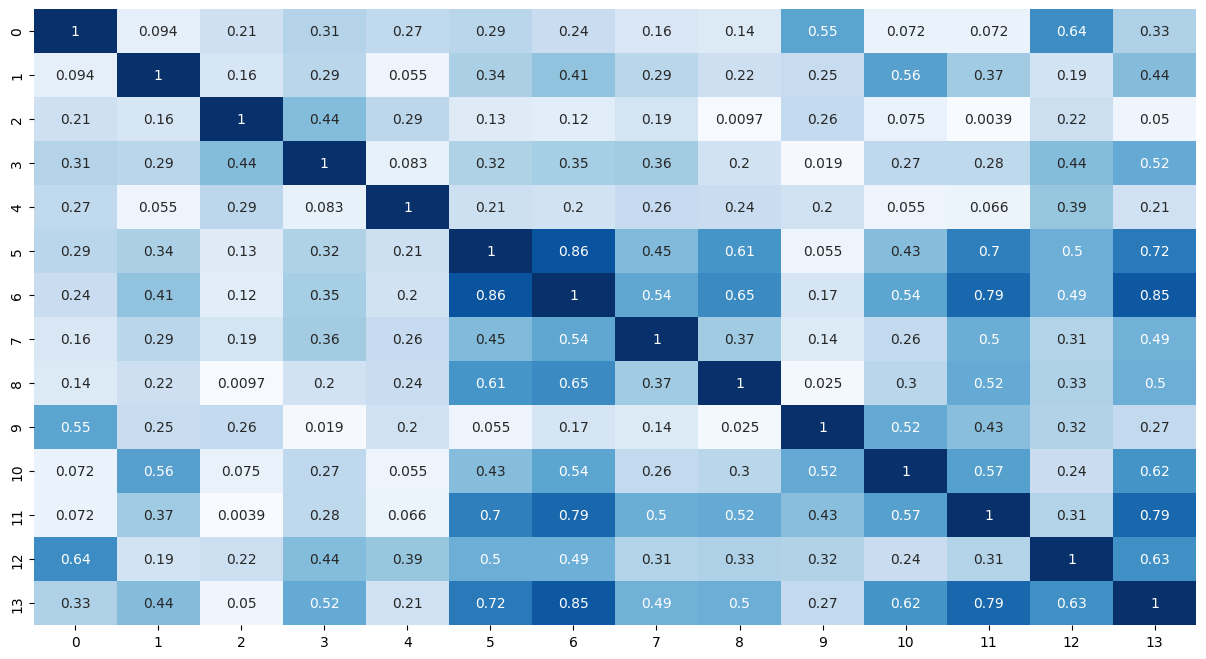

In [10]:
fig, ax = plt.subplots(figsize = (15, 8))
sns.heatmap(data_df.corr().abs(), ax = ax, cmap='Blues', fmt='.2g', cbar=False, annot=True )

# Train Test Split

In [11]:
# labels: The target dataset (dependent variable)
labels = data_df[data_df.columns[-1]]

# features_df: The feature dataset (independent variables)
features_df = data_df.drop(data_df.columns[-1], axis = 1)
features_df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [12]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    features_df,        # Feature dataset
    labels,             # Target labels
    test_size=TEST_SIZE, # Fraction of data for testing (e.g., 0.2)
    stratify=labels,    # Maintain class balance between train and test sets
    random_state=RANDOM_STATE # Seed for reproducibility
)

# Print shapes of train and test datasets
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((142, 13), (36, 13), (142,), (36,))

# Transform data

In [13]:
# Initialize the StandardScaler
# StandardScaler standardizes features by removing the mean and scaling to unit variance.
scaler = StandardScaler()

# Fit the scaler on the training set and transform it
X_train = scaler.fit_transform(X_train)

# Transform the test set using the parameters learned from the training set
X_test = scaler.transform(X_test)

# Initialize the LabelEncoder
# LabelEncoder converts categorical labels into numerical form (e.g., 'A', 'B', 'C' -> 0, 1, 2)
le = LabelEncoder()

# Fit the encoder on the training labels and transform them
y_train = le.fit_transform(y_train)

# Transform the test labels using the same mapping from the training labels
y_test = le.transform(y_test)

# Verify the types of the transformed datasets
type(X_train), type(X_test), type(y_train), type(y_test)


(numpy.ndarray, numpy.ndarray, numpy.ndarray, numpy.ndarray)

# Prepare model

In [14]:
# Define a sequential neural network model
model = nn.Sequential(
    nn.Linear(13, 8),  # Input layer: 13 input features, 8 neurons in the first hidden layer
    nn.ReLU(),         # Activation function: ReLU adds non-linearity
    nn.Linear(8, 3)    # Output layer: 3 neurons for 3 output classes (or values for regression)
)

# display the model architecture
display(model)

Sequential(
  (0): Linear(in_features=13, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=3, bias=True)
)

In [15]:
summary(model.to(device=device), (1,13))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                 [-1, 1, 8]             112
              ReLU-2                 [-1, 1, 8]               0
            Linear-3                 [-1, 1, 3]              27
Total params: 139
Trainable params: 139
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


In [16]:
# Define the loss function
# CrossEntropyLoss is suitable for multi-class classification problems.
# It combines nn.LogSoftmax() and nn.NLLLoss() in one single step for efficiency.
loss_fn = nn.CrossEntropyLoss()

# Define the optimizer
# Adam is an adaptive optimization algorithm that adjusts learning rates dynamically.
optimizer = torch.optim.Adam(
    model.parameters(),  # Pass the model parameters to optimize
    lr=0.001             # Learning rate (default: 0.001, adjust as needed)
)


In [17]:
train_x = torch.tensor(X_train, dtype= torch.float32, device=device)
train_y = torch.tensor(y_train, dtype= torch.int64, device=device) # remember this cannot be float

test_x = torch.tensor(X_test, dtype= torch.float32, device=device)
test_y = torch.tensor(y_test, dtype= torch.int64, device=device) # may not need though

### Unit Testing

In [18]:
# model(X_train[:1]) # error numpy array not expected
pred = model(train_x[:1])

pred


tensor([[ 0.3531, -0.3311, -0.2378]], device='cuda:0',
       grad_fn=<AddmmBackward0>)

In [19]:
loss_fn(pred, train_y[:1])

tensor(1.4061, device='cuda:0', grad_fn=<NllLossBackward0>)

In [20]:
for epoch in range(EPOCHS):
    model.train()  # Set the model to training mode
    
    # Forward pass: Compute model predictions for the training data
    outputs = model(train_x)  # train_x should be moved to the correct device if using GPU/CPU dynamically
    
    # Compute the loss between predictions and true labels
    loss = loss_fn(outputs, train_y)  # Ensure train_y and outputs have compatible shapes and device

    optimizer.zero_grad()  # Reset gradients to avoid accumulation from previous steps
    loss.backward()        # Backpropagate to compute gradients
    optimizer.step()       # Update the model parameters using the optimizer
    
    if epoch % 100 == 0 or epoch == EPOCHS - 1:
        print(f'At epoch {epoch:4d} | Loss: {loss.item():.4f}')  # Use loss.item() to extract the scalar value


At epoch    0 | Loss: 1.1113
At epoch  100 | Loss: 0.6188
At epoch  200 | Loss: 0.2636
At epoch  300 | Loss: 0.1236
At epoch  400 | Loss: 0.0761
At epoch  500 | Loss: 0.0537
At epoch  600 | Loss: 0.0405
At epoch  700 | Loss: 0.0317
At epoch  800 | Loss: 0.0255
At epoch  900 | Loss: 0.0205
At epoch  999 | Loss: 0.0164


# Evaluate

In [21]:
# Set the model to evaluation mode (important for layers like dropout or batch norm)
model.eval()

# Disable gradient computation for inference to improve performance and save memory
with torch.no_grad():
    
    # Make predictions on the training data
    train_pred = model(train_x)

    # Make predictions on the testing data
    test_pred = model(test_x)

# Check the types of the predictions
type(train_pred), type(test_pred)


(torch.Tensor, torch.Tensor)

**Note**:
- y_train_pred is a tensor of shape m x 3
- convert to numpy
- argmax to get prediction

In [22]:
train_pred

tensor([[ 3.4295e-05,  3.0138e+00, -6.4564e+00],
        [-4.4611e+00,  4.7593e+00, -5.6596e+00],
        [-4.1565e+00,  4.4572e+00, -5.7584e+00],
        [-5.5807e+00,  5.2132e+00, -5.5632e+00],
        [-2.2627e+00, -1.0269e+00,  3.7168e+00],
        [ 3.9846e+00, -1.8188e+00, -2.4715e+00],
        [ 5.1205e+00, -2.5848e+00, -3.8103e+00],
        [ 3.0486e+00, -1.4161e+00, -1.9503e+00],
        [-1.0230e+00,  1.7078e+00, -2.7930e+00],
        [-1.4410e+00, -3.3671e+00,  6.2394e+00],
        [-2.5471e+00,  1.2324e+00,  4.6652e-01],
        [-4.9862e+00,  4.2039e+00, -4.8136e+00],
        [ 3.0674e+00, -1.6107e+00, -1.8724e+00],
        [-1.1647e+00, -1.7919e+00,  3.7847e+00],
        [ 5.8317e+00, -3.1257e+00, -2.9830e+00],
        [-3.3824e+00,  4.0888e+00, -4.8828e+00],
        [ 5.2236e+00, -2.8159e+00, -2.7495e+00],
        [-3.8904e+00,  3.2496e+00, -2.6101e+00],
        [ 6.5668e+00, -3.9138e+00, -3.1680e+00],
        [-4.2840e+00,  3.9553e+00, -4.2835e+00],
        [ 4.2279e+00

In [23]:
y_train_pred = train_pred.detach()  # Remove the computation graph (no gradients)
y_train_pred = y_train_pred.cpu().numpy()  # Convert tensor to NumPy array
y_train_pred = y_train_pred.argmax(axis=1)  # Convert logits to predicted class labels
y_train_pred

array([1, 1, 1, 1, 2, 0, 0, 0, 1, 2, 1, 1, 0, 2, 0, 1, 0, 1, 0, 1, 0, 2,
       1, 0, 2, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 2, 0, 1, 2, 2, 1, 0,
       1, 1, 0, 2, 0, 1, 1, 2, 1, 2, 1, 1, 1, 0, 0, 2, 2, 0, 2, 0, 1, 1,
       2, 0, 0, 2, 0, 2, 2, 2, 2, 0, 1, 1, 1, 0, 2, 0, 0, 1, 2, 2, 2, 2,
       1, 1, 1, 0, 1, 2, 1, 2, 0, 2, 1, 0, 2, 1, 1, 1, 1, 1, 2, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 2, 0, 2, 1, 0, 1, 1, 1, 1, 1, 2, 2, 1,
       2, 1, 2, 1, 0, 1, 1, 0, 2, 2])

In [24]:
accuracy_score(y_train, y_train_pred)

1.0

In [25]:
print(classification_report(y_train, y_train_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        47
           1       1.00      1.00      1.00        57
           2       1.00      1.00      1.00        38

    accuracy                           1.00       142
   macro avg       1.00      1.00      1.00       142
weighted avg       1.00      1.00      1.00       142



# How am I doing on Test Data

In [26]:
y_test_pred = test_pred.detach().cpu().numpy().argmax(axis = 1) # becomes np.ndarray of shape m x 1
y_test_pred

array([1, 2, 1, 0, 0, 1, 2, 1, 0, 0, 1, 1, 2, 0, 1, 2, 0, 2, 0, 0, 1, 1,
       1, 0, 0, 2, 1, 1, 1, 1, 2, 0, 2, 2, 0, 2])

In [27]:
accuracy_score(y_test, y_test_pred)

1.0

In [28]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



In [29]:
confusion_matrix(y_test, y_test_pred)

array([[12,  0,  0],
       [ 0, 14,  0],
       [ 0,  0, 10]])

### We need loss curves

In [ ]:
# Initialize lists to store the loss values for later analysis (e.g., plotting)
test_loss, train_loss = [], []

for epoch in range(EPOCHS):
    # Set the model to training mode
    model.train()
    
    # Forward pass: Compute model predictions for the training data
    outputs = model(train_x)  # train_x is the input training data
    loss = loss_fn(outputs, train_y)  # Compute the loss using the predicted outputs and true labels (train_y)

    # Back-propagation: Zero gradients, compute new gradients, and update model parameters
    optimizer.zero_grad()  # Clear the gradients from the previous step
    loss.backward()        # Back-propagate to compute gradients
    optimizer.step()       # Update the model parameters using the optimizer

    # Store the training loss for this epoch
    train_loss.append(loss.item())  # loss.item() returns the scalar value of the loss, not a tensor

    # No gradient computation needed during evaluation, so we disable it
    with torch.no_grad():  # Disable gradients for the validation phase (saves memory and computation)
        
        # Set the model to evaluation mode (important for layers like dropout or batch norm)
        model.eval()

        # Forward pass: Compute model predictions for the test data
        outputs = model(test_x)  # test_x is the input test data
        tloss = loss_fn(outputs, test_y)  # Compute the test loss using the predicted outputs and true test labels

        # Store the test loss for this epoch
        test_loss.append(tloss.item())  # store test loss in list

    # Print progress at each epoch
    if epoch % 100 == 0 or epoch == EPOCHS - 1:
        print(f'At epoch {epoch:3d} | Train Loss: {loss.item():.4f} | Test Loss: {tloss.item():.4f}')


At epoch   0 | Train Loss: 0.0163 | Test Loss: 0.0214
At epoch 100 | Train Loss: 0.0136 | Test Loss: 0.0185
At epoch 200 | Train Loss: 0.0115 | Test Loss: 0.0164
At epoch 300 | Train Loss: 0.0098 | Test Loss: 0.0146
At epoch 400 | Train Loss: 0.0084 | Test Loss: 0.0132
At epoch 500 | Train Loss: 0.0073 | Test Loss: 0.0120
At epoch 600 | Train Loss: 0.0063 | Test Loss: 0.0111
At epoch 700 | Train Loss: 0.0056 | Test Loss: 0.0101
At epoch 800 | Train Loss: 0.0049 | Test Loss: 0.0093
At epoch 900 | Train Loss: 0.0043 | Test Loss: 0.0085
At epoch 999 | Train Loss: 0.0039 | Test Loss: 0.0079


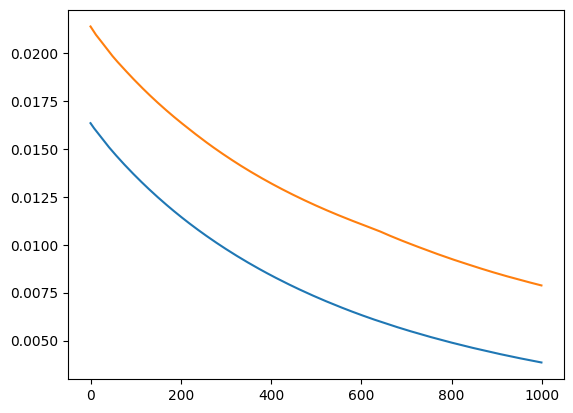

In [31]:
fig, ax = plt.subplots()

ax.plot(train_loss, label='Train')
ax.plot(test_loss, label='Test');
